In [30]:
SCOPETYPE = 'OPENADC'
PLATFORM = 'CWLITEARM'
CRYPTO_TARGET='NONE' 
SS_VER='SS_VER_1_1'

In [31]:
# Adapt this to your ChipWhisperer installation
%run "../Setup_Scripts/Setup_Generic.ipynb"

INFO: Found ChipWhisperer😍
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 6938908                   to 17505319                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 18834308                  to 29538459                 
scope.clock.adc_rate                     changed from 18834308.0                to 29538459.0        

In [32]:
samples = 3500
scope.adc.samples = samples

In [33]:
%%bash -s "$PLATFORM" "$CRYPTO_TARGET" "$SS_VER" 
cd target
make clean PLATFORM=$1 CRYPTO_TARGET=$2 SS_VER=$3 -j
make PLATFORM=$1 CRYPTO_TARGET=$2 SS_VER=$3 -j

SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
rm -f -- MaskedGeometric-CW308_CC2538.hex MaskedGeometric-CW301_AVR.hex MaskedGeometric-CW303.hex MaskedGeometric-CW304.hex MaskedGeometric-CW308_MEGARF.hex MaskedGeometric-CW308_SAM4L.hex MaskedGeometric-CW308_STM32F0.hex MaskedGeometric-CW308_STM32F1.hex MaskedGeometric-CW308_STM32F2.hex MaskedGeometric-CW308_STM32F3.hex MaskedGeometric-CW308_STM32F4.hex MaskedGeometric-CW308_K24F.hex MaskedGeometric-CW308_NRF52.hex MaskedGeometric-CW308_AURIX.hex MaskedGeometric-CW308_SAML11.hex MaskedGeometric-CW308_EFM32TG11B.hex MaskedGeometric-CWLITEARM.hex MaskedGeometric-CWLITEXMEGA.hex MaskedGeometric-CWNANO.hex MaskedGeometric-CWHUSKY.hex MaskedGeometric-CW308_K82F.hex MaskedGeometric-CW308_PSOC62.hex MaskedGeometric-CW308_IMXRT1062.hex MaskedGeometric-CW308_FE310.hex MaskedGeometric-CW308_EFR32MG21A.hex MaskedGeometric-CW308_EFM32GG11.hex MaskedGeometric-CW308_STM32L5.hex MaskedGeometric-CW308_NEORV32.hex MaskedGeometric-CW312_SAM4S.hex Mask

In [34]:
cw.program_target(scope, prog, "target/MaskedGeometric-{}.hex".format(PLATFORM))

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 21807 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 21807 bytes


In [39]:
from secrets import token_bytes
from random import randint
from tqdm.notebook import trange
from secrets import randbits
import numpy as np

PT_LEN = 32
RESP_LEN = 1

def get_traces(N):
    traces_fixed = []
    traces_random = []

    fixed_sample_seed = bytes([0x00] * 16)

    for i in trange(N, desc='Capturing traces'):
        scope.arm()
        
        is_fixed = bool(randbits(1)) # randomly choose fixed or random class

        if is_fixed:
            sample_seed = fixed_sample_seed
        else:
            sample_seed = token_bytes(16)
         
        mask_seed = token_bytes(16) # fresh, independent masking randomness

        pt = bytearray(sample_seed + mask_seed)
        assert len(pt) == PT_LEN

        target.simpleserial_write('p', pt)

        ret = scope.capture()
        t = scope.adc.trig_count

        if ret:
            print("Target timed out!")
            continue

        response = target.simpleserial_read('r', RESP_LEN)
        if response is None or len(response) != RESP_LEN:
            print("Invalid response:", response)
            continue

        trace = scope.get_last_trace()

        if is_fixed:
            traces_fixed.append(trace)
        else:
            traces_random.append(trace)

    size = min(len(traces_fixed), len(traces_random))
    
    print("Trigger up for", t, "ADC cycles")
    return (traces_fixed[:size], traces_random[:size])

In [41]:
ch = 0
if ch == 0:
    VERBOSE = False
    nb_traces = 200000
    traces_1, traces_2 = get_traces(nb_traces)
else:
    VERBOSE = True
    nb_traces = 100
    traces_1, traces_2 = get_traces(nb_traces)

Capturing traces:   0%|          | 0/200000 [00:00<?, ?it/s]

Trigger up for 3488 ADC cycles


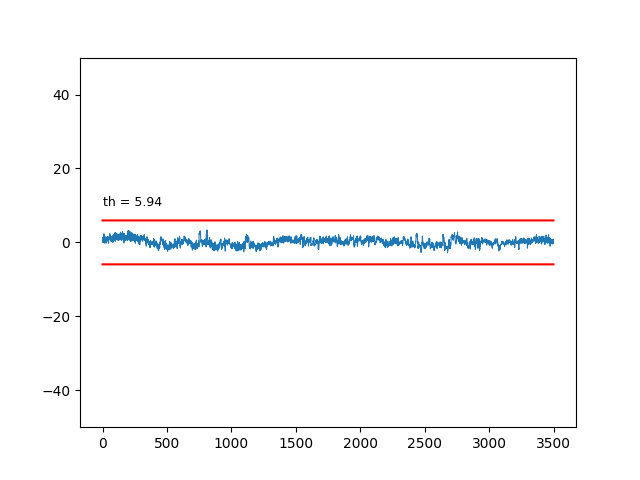

In [29]:
%matplotlib ipympl
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import norm

alpha = 10**(-5) # error rate
sigma = 1 - (1 - alpha)**(1/samples)
th = norm.ppf(1 - sigma/2) # we adapt the threshold depending on number of samples
t_val = ttest_ind(traces_1, traces_2, axis=0, equal_var=False)[0]
plt.close()
plt.plot(t_val[0:], linewidth=0.75)
plt.plot([th]*scope.adc.samples, color = 'r')
plt.plot([-th]*scope.adc.samples, color='r')
y_offset = 0.5 * th  
plt.text(
    2,                  
    th + y_offset,
    f"th = {th:.2f}",
    color='black',
    fontsize=9,
    verticalalignment='bottom'
)
plt.ylim(-50, 50)
plt.show()

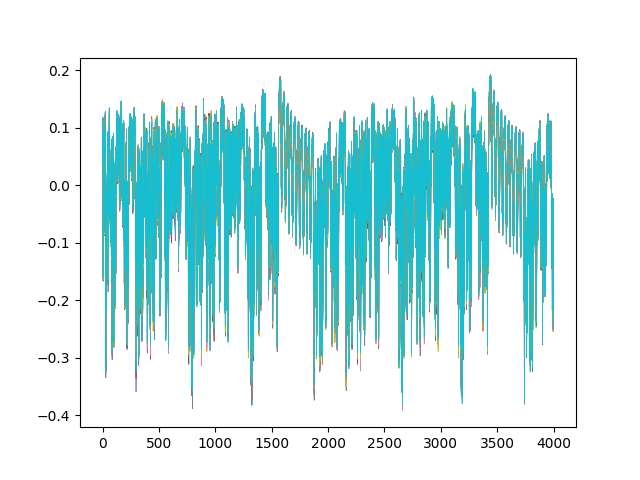

In [64]:
%matplotlib ipympl
import matplotlib.pyplot as plt

plt.close()
for t in traces_1[:10]:
    plt.plot(t[:], linewidth=0.5)
plt.show()

In [28]:
target.dis()
scope.dis()

True